In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np
sys.path.append("..")
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

/home/zczhang/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# read from json
data = None
experiment_name = "fig2"
with open("../../../output/oscar-nsdi26/experiments/" + experiment_name + ".json", "r") as f:
    data = json.load(f)

In [3]:
# Calculate the send rate from data{flowStatistics:[0:4]:sentPkt:[timeNs,sizeByte]}
# The send rate is calculated by the number Bytes sent in each time interval
send_rate_interval_ns = 1.15e4  # 10us
send_rate = []
flow_num = 5
for i in range(flow_num):
    send_rate.append([])
    wnd_start = data["flowStatistics"][i]["sentPkt"][0]["timeNs"]
    # the first point
    send_rate[i].append({"timeNs": wnd_start, "sendRateGbps": 0})
    wnd_data = 0
    for spi, sentPkt in enumerate(data["flowStatistics"][i]["sentPkt"]):
        if sentPkt["timeNs"] - wnd_start > 1.5*send_rate_interval_ns:
            # Gbps = bpns
            # calculate the send rate using previous data
            if data["flowStatistics"][i]["sentPkt"][spi-1]["timeNs"] != wnd_start:
                send_rate[i].append({
                    "timeNs": (wnd_start + data["flowStatistics"][i]["sentPkt"][spi-1]["timeNs"])/2,
                    "sendRateGbps": wnd_data * 8 / (data["flowStatistics"][i]["sentPkt"][spi-1]["timeNs"] - wnd_start + (data["flowStatistics"][i]["sentPkt"][spi-1]["timeNs"] - data["flowStatistics"][i]["sentPkt"][spi-2]["timeNs"]))})
            send_rate[i].append({"timeNs": data["flowStatistics"][i]["sentPkt"][spi-1]["timeNs"],
                                "sendRateGbps": 0})
            send_rate[i].append({"timeNs": sentPkt["timeNs"],
                                "sendRateGbps": 0})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        elif sentPkt["timeNs"] - wnd_start > send_rate_interval_ns:
            # Gbps = bpns
            send_rate[i].append({"timeNs": wnd_start + (sentPkt["timeNs"] - wnd_start)/2,
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        wnd_data += sentPkt["sizeByte"]
    # the last point
    send_rate[i].append({"timeNs": wnd_start + send_rate_interval_ns/2,
                         "sendRateGbps": 0})

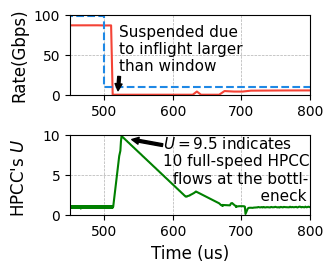

In [4]:
# draw the send rate in a new figure
fig, axs = plt.subplots(2, 1, figsize=(3, 2.5), gridspec_kw={
                        'height_ratios': [1,1]})
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)

ax1 = axs[0]
ax1.set_ylabel("Rate(Gbps)", fontsize=12)

# the fair share line
time_begin = 100.5e6
time_end = 101.5e6
fair_share = [{
    "timeNs": 100e6,
    "sendRateGbps": 99
},
    {
    "timeNs": time_begin,
    "sendRateGbps": 99
},
    {
    "timeNs": time_begin,
    "sendRateGbps": 10
},
    {
    "timeNs": time_end,
    "sendRateGbps": 10
},
    {
    "timeNs": time_end,
    "sendRateGbps": 99
},
    {
    "timeNs": 102e6,
    "sendRateGbps": 99
}]

color_rate = ["#F44336", "#1E88E5"]
color_queue = ["#4E342E", "#FB8C00"]
color_signal = "#008000"
line = ["-", "--"]

legend_lines = []

time_shift = 100e3

legend_line = ax1.plot([s["timeNs"]/1e3 - time_shift for s in send_rate[0]],
         [87]+[s["sendRateGbps"] for s in send_rate[0]][1:], label="HPCC", color=color_rate[0], linestyle=line[0])
legend_lines.append(legend_line[0])
legend_line = ax1.plot([s["timeNs"]/1e3 - time_shift for s in fair_share],
         [s["sendRateGbps"] for s in fair_share], label="Fair share", color=color_rate[1], linestyle=line[1])
legend_lines.append(legend_line[0])
ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax1.set_xlim(450, 800)
ax1.set_ylim(0, 100)

ax2 = axs[1]
ax2.set_xlabel("Time (us)", fontsize=12)
fig.text(-0.1, 0.25, "HPCC's $U$", va='center', rotation='vertical', fontsize=12)
legend_line = ax2.plot([u["timeNs"]/1e3 - time_shift for u in data["flowStatistics"][0]["ccStats"]["u"]],
         [u["u"] for u in data["flowStatistics"][0]["ccStats"]["u"]], label="HPCC's U from INT", color=color_signal, linestyle=line[0])
legend_lines.append(legend_line[0])
ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')
ax2.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')
ax2.set_ylim(0, 10)
ax2.set_xlim(450, 800)


ax1.annotate('Suspended due \nto inflight larger \nthan window', xy=(520, 5), xytext=(522, 30),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5), fontsize=11
             )
ax2.annotate('$U=9.5$ indicates \n10 full-speed HPCC \n  flows at the bottl-\n                    eneck',
             xy=(520, 5), xytext=(586, 1.8),
             xycoords='data', fontsize=11
             )
ax2.annotate('', xy=(540, 9.4), xytext=(585, 8.7),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)

# save as pdf
plt.savefig("../figures/" + "fig2a" +
             ".pdf", bbox_inches='tight', dpi=600, format='pdf')

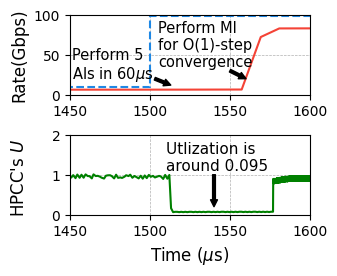

In [5]:
# draw the send rate in a new figure
fig, axs = plt.subplots(2, 1, figsize=(3, 2.5), gridspec_kw={
                        'height_ratios': [1,1]})
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)

ax1 = axs[0]
ax1.set_ylabel("Rate(Gbps)", fontsize=12)

# the fair share line
time_begin = 100.5e6
time_end = 101.5e6
fair_share = [{
    "timeNs": 100e6,
    "sendRateGbps": 99
},
    {
    "timeNs": time_begin,
    "sendRateGbps": 99
},
    {
    "timeNs": time_begin,
    "sendRateGbps": 10
},
    {
    "timeNs": time_end,
    "sendRateGbps": 10
},
    {
    "timeNs": time_end,
    "sendRateGbps": 99
},
    {
    "timeNs": 102e6,
    "sendRateGbps": 99
}]

color_rate = ["#F44336", "#1E88E5"]
color_queue = ["#4E342E", "#FB8C00"]
color_signal = "#008000"
line = ["-", "--"]

legend_lines = []

time_shift = 100e3

legend_line = ax1.plot([s["timeNs"]/1e3 - time_shift for s in send_rate[0]],
         [87]+[s["sendRateGbps"] for s in send_rate[0]][1:], label="HPCC", color=color_rate[0], linestyle=line[0])
legend_lines.append(legend_line[0])
legend_line = ax1.plot([s["timeNs"]/1e3 - time_shift for s in fair_share],
         [s["sendRateGbps"] for s in fair_share], label="Fair share", color=color_rate[1], linestyle=line[1])
legend_lines.append(legend_line[0])
ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax1.set_xlim(1450, 1600)
ax1.set_ylim(0, 100)

ax2 = axs[1]
ax2.set_xlabel("Time ($\mu$s)", fontsize=12)
fig.text(-0.1, 0.25, "HPCC's $U$", va='center', rotation='vertical', fontsize=12)
legend_line = ax2.plot([u["timeNs"]/1e3 - time_shift for u in data["flowStatistics"][0]["ccStats"]["u"]],
         [u["u"] for u in data["flowStatistics"][0]["ccStats"]["u"]], label="HPCC's U from INT", color=color_signal, linestyle=line[0])
legend_lines.append(legend_line[0])
ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')
ax2.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')
ax2.set_ylim(0, 2)
ax2.set_xlim(1450, 1600)


ax1.annotate('', xy=(1513, 12), xytext=(1503, 20),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)
ax1.annotate('Perform 5 \nAIs in 60$\mu$s', xy=(1520, 5), xytext=(1451, 20),
             xycoords='data', fontsize=10.5)

ax1.annotate('', xy=(1560, 20), xytext=(1550, 30),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)
ax1.annotate('Perform MI \nfor O(1)-step \nconvergence', xy=(1520, 5), xytext=(1505, 35),
             xycoords='data', fontsize=10.5)

ax2.annotate('', xy=(1540, 0.2), xytext=(1540, 1.),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)
ax2.annotate('Utlization is \naround 0.095', xy=(1450, 0), xytext=(1510, 1.1),
             xycoords='data', fontsize=11)

plt.savefig("../figures/" + "fig2b" +
             ".pdf", bbox_inches='tight', dpi=600, format='pdf')

In [6]:
figlegend = plt.figure(figsize=(12,1))
plt.subplots_adjust(left=0.1, right=0.9, top=0.8, bottom=0.2)

label_names = ["Goodput of the long flow", "Fair share", "HPCC's $U$ from INT"]
legend_lines = [legend_lines[0], legend_lines[1], legend_lines[2]]

figlegend.legend(legend_lines, label_names, loc='center', ncol=len(label_names), frameon=False)
# save as pdf
plt.savefig("../figures/" + "fig2-legend" +
             ".pdf", bbox_inches='tight', pad_inches=0.0, dpi=600, format='pdf')

<Figure size 1200x100 with 0 Axes>